## 1. Import Libraries

In [28]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset



## 2. Load Dataset

In [29]:
df = pd.read_csv("data.csv", encoding="latin1")
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


## 3. Initial Data Inspection
Checking data types, summary statistics, and overall structure.

In [30]:
print(f'='*50+" info "+"="*50)
print(df.info())
print(f'='*50+" descibe of data "+"="*50)
print (df.describe())
print(f"="*50+" columns "+"="*50)
print((df.columns).tolist ())
print(f'='*50+" shape of data "+"="*50)

df.shape



================================================== info ==================================================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None
================================================== descibe of data ==================================================
            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.

(541909, 8)

## 4. Missing Values & Data Quality Check

In [31]:
print(f"="*50+" count null for evrey columns "+"="*50)
print((df.isna()).sum())
print(f'='*50+" Quantity of negative "+"="*50)

print(df[df["Quantity"]<0].shape)
print(f'='*50+" UnitPrice of negative "+"="*50)

print(df[df["UnitPrice"]<=0].shape)
print(f'='*50+" InvoiceNo clancelled "+"="*50)

print(df[df['InvoiceNo'].str.startswith("C")].shape)

print("\n Customers nunique :")
print(df['CustomerID'].nunique())

print("\n count Countryes :")
print(df['Country'].nunique())
print(df['Country'].value_counts().head(10))



================================================== count null for evrey columns ==================================================
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
================================================== Quantity of negative ==================================================
(10624, 8)
================================================== UnitPrice of negative ==================================================
(2517, 8)
================================================== InvoiceNo clancelled ==================================================
(9288, 8)

 Customers nunique :
4372

 count Countryes :
38
Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1

## 5. Check for Duplicates

In [32]:
df.duplicated().sum()

5268

## 6. Data Cleaning
Removing nulls, duplicates, and invalid transactions (cancelled orders, negative quantities).

In [33]:
print(f"Before cleaning: {df.shape}")
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df = df[~df['InvoiceNo'].str.startswith('C')]
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df['CustomerID'] = df['CustomerID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print(f"After cleaning: {df.shape}")
print(f"Rows removed: {541909 - df.shape[0]}")
print(f"\nFirst 3 rows:")
print(df.head(3))
print(f"\nData types after cleaning:")
print(df.dtypes)


Before cleaning: (541909, 8)
After cleaning: (392692, 9)
Rows removed: 149217

First 3 rows:
  InvoiceNo StockCode                         Description  Quantity  \
0    536365    85123A  WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                 WHITE METAL LANTERN         6   
2    536365    84406B      CREAM CUPID HEARTS COAT HANGER         8   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalPrice  
0 2010-12-01 08:26:00       2.55       17850  United Kingdom       15.30  
1 2010-12-01 08:26:00       3.39       17850  United Kingdom       20.34  
2 2010-12-01 08:26:00       2.75       17850  United Kingdom       22.00  

Data types after cleaning:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int32
Country                object
TotalPrice            float64
dtype: object


## 7. RFM Feature Engineering
Calculating **Recency**, **Frequency**, and **Monetary** value for each customer.

In [34]:
refrance_date = df["InvoiceDate"].max() + datetime.timedelta(days=1)
print (f"{refrance_date}")

rfm = df.groupby(df["CustomerID"]).agg(
    Recency = ("InvoiceDate", lambda x: (refrance_date - x.max()).days),
    Frequency = ("InvoiceNo","nunique"),
    Monetary = ("TotalPrice","sum")
).reset_index()

print(f"\nRFM shape: {rfm.shape}")
print(f"\nFirst 5 rows:")
print(rfm.head(5))
print(f"\nRFM Statistics:")
print(rfm[['Recency','Frequency','Monetary']].describe())



2011-12-10 12:50:00

RFM shape: (4338, 4)

First 5 rows:
   CustomerID  Recency  Frequency  Monetary
0       12346      326          1  77183.60
1       12347        2          7   4310.00
2       12348       75          4   1797.24
3       12349       19          1   1757.55
4       12350      310          1    334.40

RFM Statistics:
           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2048.688081
std     100.014169     7.697998    8985.230220
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     306.482500
50%      51.000000     2.000000     668.570000
75%     142.000000     5.000000    1660.597500
max     374.000000   209.000000  280206.020000


## 8. RFM Distribution
Visualizing the distribution of the three RFM metrics before transformation.

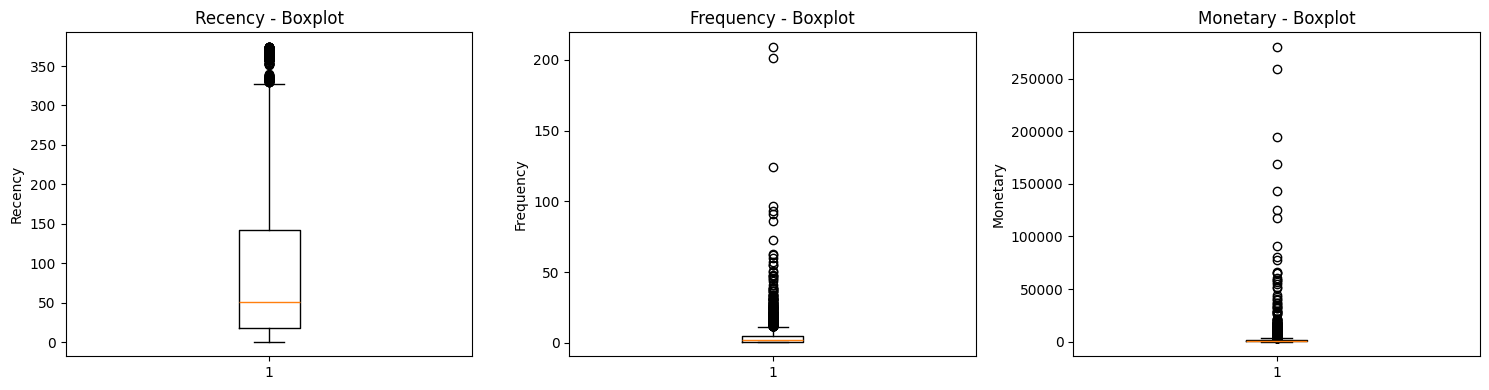

Recency outliers: 155 (3.6%)
Frequency outliers: 285 (6.6%)
Monetary outliers: 425 (9.8%)


In [35]:


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    axes[i].boxplot(rfm[col])
    axes[i].set_title(f'{col} - Boxplot')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.savefig('rfm_boxplots.png', dpi=150)
plt.show()

for col in ['Recency', 'Frequency', 'Monetary']:
    Q1 = rfm[col].quantile(0.25)
    Q3 = rfm[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = rfm[(rfm[col] < Q1 - 1.5*IQR) | (rfm[col] > Q3 + 1.5*IQR)]
    print(f"{col} outliers: {len(outliers)} ({len(outliers)/len(rfm)*100:.1f}%)")

## 9. Log Transform & Scaling
Applying log transformation to reduce skewness, then scaling features for clustering.

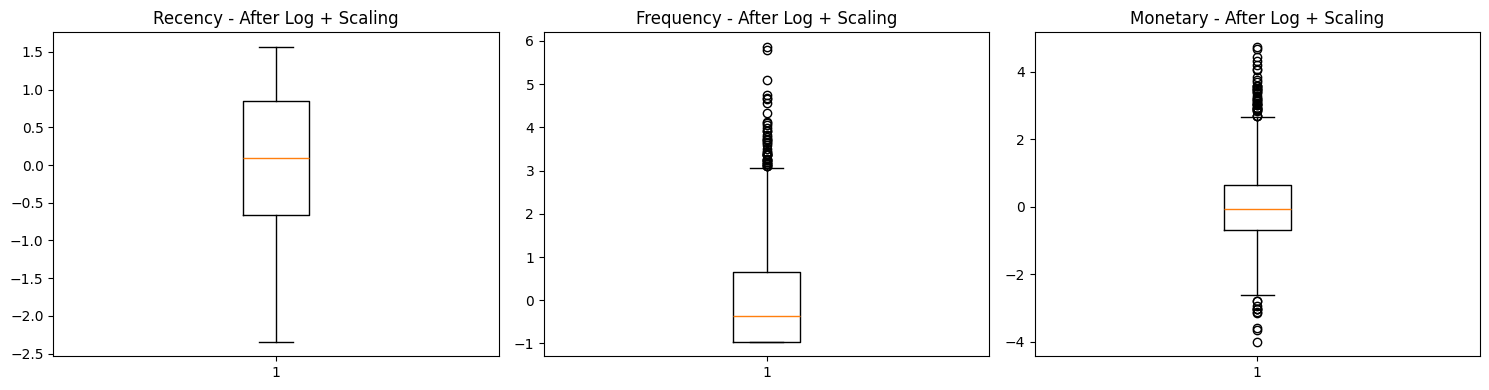

Scaled statistics:
       Recency  Frequency  Monetary
count  4338.00    4338.00   4338.00
mean     -0.00      -0.00     -0.00
std       1.00       1.00      1.00
min      -2.34      -0.96     -4.00
25%      -0.66      -0.96     -0.68
50%       0.09      -0.36     -0.07
75%       0.84       0.65      0.66
max       1.56       5.86      4.73


In [36]:
rfm_log = rfm.copy()
rfm_log['Recency']   = np.log1p(rfm['Recency'])
rfm_log['Frequency'] = np.log1p(rfm['Frequency'])
rfm_log['Monetary']  = np.log1p(rfm['Monetary'])


scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log[['Recency', 'Frequency', 'Monetary']])
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    axes[i].boxplot(rfm_scaled[col])
    axes[i].set_title(f'{col} - After Log + Scaling')

plt.tight_layout()
plt.savefig('rfm_scaled_boxplots.png', dpi=150)
plt.show()

print("Scaled statistics:")
print(rfm_scaled.describe().round(2))

## 10. Optimal K Selection
Using the Elbow Method and Silhouette Score to determine the best number of clusters.

Testing K values...
K=2 | Inertia: 6484 | Silhouette: 0.433
K=3 | Inertia: 4869 | Silhouette: 0.337
K=4 | Inertia: 3939 | Silhouette: 0.338
K=5 | Inertia: 3297 | Silhouette: 0.316
K=6 | Inertia: 2856 | Silhouette: 0.312
K=7 | Inertia: 2549 | Silhouette: 0.309
K=8 | Inertia: 2336 | Silhouette: 0.303
K=9 | Inertia: 2156 | Silhouette: 0.281
K=10 | Inertia: 2006 | Silhouette: 0.277


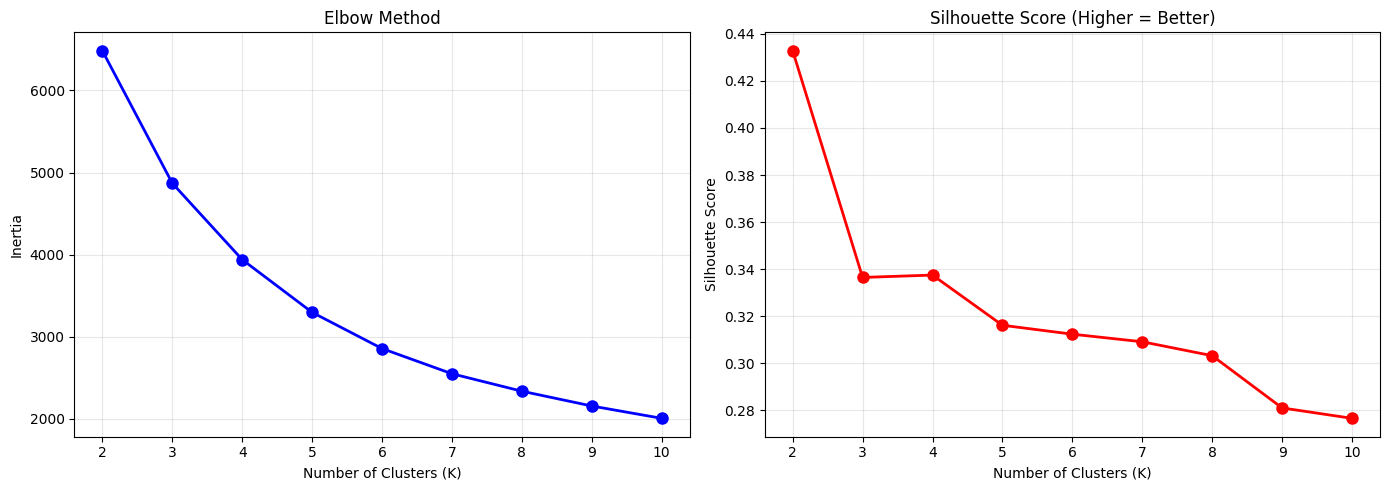

In [37]:

inertia = []
silhouette_scores = []
K_range = range(2, 11)

print("Testing K values...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)
    score = silhouette_score(rfm_scaled, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"K={k} | Inertia: {kmeans.inertia_:.0f} | Silhouette: {score:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (Higher = Better)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150)
plt.show()

## 11. K-Means Clustering
Clustering customers into segments based on scaled RFM features.

In [38]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print("Customers per cluster:")
print(rfm['Cluster'].value_counts().sort_index())

print("\nCluster profiles (original values):")
print(rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(0))

Customers per cluster:
Cluster
0     713
1    1622
2     837
3    1166
Name: count, dtype: int64

Cluster profiles (original values):
         Recency  Frequency  Monetary
Cluster                              
0           12.0       14.0    8088.0
1          182.0        1.0     341.0
2           18.0        2.0     557.0
3           72.0        4.0    1802.0


## 12. Segment Labeling
Assigning business-meaningful names to each cluster based on RFM profile averages.

In [39]:

segment_names = {
    0: 'VIP',
    1: 'Lost',
    2: 'New',
    3: 'Loyal'
}

rfm['Segment'] = rfm['Cluster'].map(segment_names)

print("Segment distribution:")
print(rfm['Segment'].value_counts())

Segment distribution:
Segment
Lost     1622
Loyal    1166
New       837
VIP       713
Name: count, dtype: int64


## 13. 3D Cluster Visualization
Visualizing customer segments in 3D RFM space.

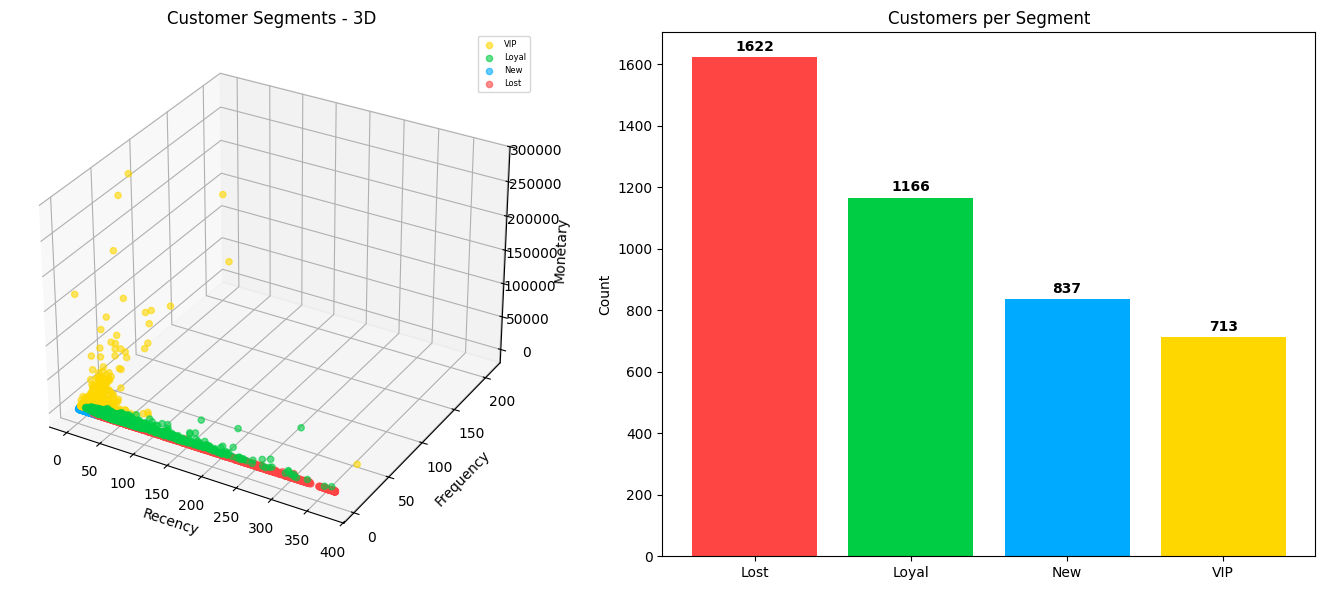

In [40]:
from mpl_toolkits.mplot3d import Axes3D

colors = {
    'VIP':   '#FFD700',
    'Loyal': '#00CC44',
    'New':   '#00AAFF',
    'Lost':  '#FF4444'
}

fig = plt.figure(figsize=(14, 6))


ax1 = fig.add_subplot(121, projection='3d')
for segment, color in colors.items():
    mask = rfm['Segment'] == segment
    ax1.scatter(
        rfm[mask]['Recency'],
        rfm[mask]['Frequency'],
        rfm[mask]['Monetary'],
        c=color, label=segment, alpha=0.6, s=20
    )
ax1.set_xlabel('Recency')
ax1.set_ylabel('Frequency')
ax1.set_zlabel('Monetary')
ax1.set_title('Customer Segments - 3D')
ax1.legend(fontsize=6)


ax2 = fig.add_subplot(122)
segment_counts = rfm['Segment'].value_counts()
bars = ax2.bar(segment_counts.index, segment_counts.values,
               color=[colors[s] for s in segment_counts.index])
ax2.set_title('Customers per Segment')
ax2.set_ylabel('Count')
for bar, val in zip(bars, segment_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(val), ha='center', fontweight='bold')

plt.tight_layout()

plt.show()